In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [5]:
#load data from pipeline
df = pd.read_csv('commodity_data.csv', index_col='Date', parse_dates=True)
#create spread
spread = df['Brent'] - df['WTI']

print (f'Date range: {df.index.min()} to {df.index.max()}')
print (f'Latest spread: {spread.iloc[-1]:.2f}')


Date range: 2019-01-02 00:00:00 to 2026-07-01 00:00:00
Latest spread: 3.15


In [6]:
#Measuring distance from average → Z score
#Measuring how much something moves → Standard deviation
#Measuring relationship between two things → Correlation
#Measuring trend strength → Moving averages

# CALCULATE MEAN REVERSION METRICS
rolling_mean = spread.rolling(window=30).mean()
rolling_std = spread.rolling(window=30).std()

# CALCULATE Z SCORE
# Z score measures how far the spread is from its average in standard deviations
zscore = (spread - rolling_mean) / rolling_std

print(f'30 Day Mean:        ${rolling_mean.iloc[-1]:.2f}')
print(f'30 Day Std Dev:     ${rolling_std.iloc[-1]:.2f}')
print(f'Current Z Score:     {zscore.iloc[-1]:.2f}')


30 Day Mean:        $3.56
30 Day Std Dev:     $1.40
Current Z Score:     -0.29


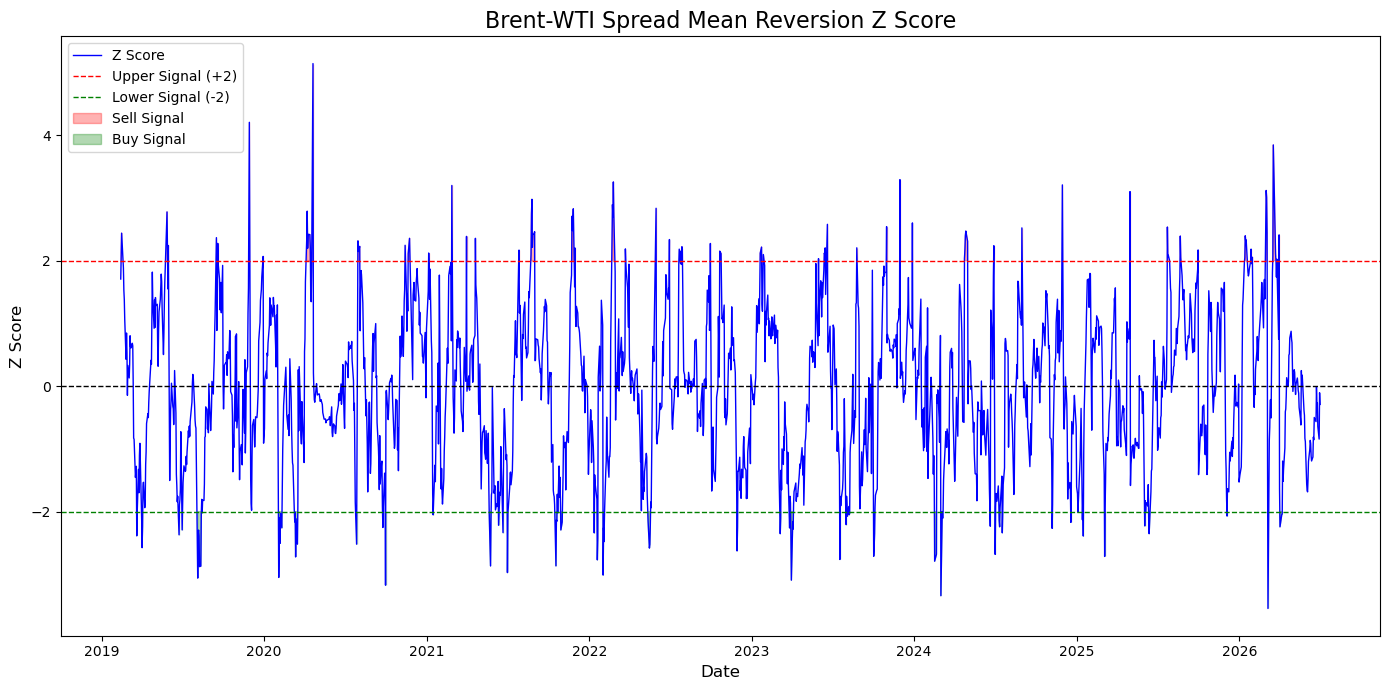

In [7]:
# PLOT Z SCORE
plt.figure(figsize=(14,7))
plt.plot(zscore, label='Z Score', color='blue', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(2, color='red', linestyle='--', linewidth=1, label='Upper Signal (+2)')
plt.axhline(-2, color='green', linestyle='--', linewidth=1, label='Lower Signal (-2)')
plt.fill_between(zscore.index, zscore, 2,
                 where=(zscore > 2), color='red', alpha=0.3, label='Sell Signal')
plt.fill_between(zscore.index, zscore, -2,
                 where=(zscore < -2), color='green', alpha=0.3, label='Buy Signal')
plt.title('Brent-WTI Spread Mean Reversion Z Score', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Z Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('mean_reversion.png', dpi=150, bbox_inches='tight')
plt.show()

Key observations:

COVID 2020 — the massive spike to +5 is the most extreme reading in the dataset, spread blew out dramatically then snapped back fast
2026 — you can see it recently hit nearly +4 then immediately crashed below -2, that's the ceasefire event playing out in real time on this chart
The signals fire regularly — there have been numerous +2 and -2 crossings across the period, suggesting this spread is genuinely mean reverting and potentially tradeable


In [8]:
# SIGNAL SUMMARY
buy_signals = (zscore < -2).sum()
sell_signals = (zscore > 2).sum()
current_signal = 'Buy' if zscore.iloc[-1] < -2 else 'Sell' if zscore.iloc[-1] > 2 else 'Neutral'

print('=' * 40)
print('MEAN REVERSION SIGNAL SUMMARY')
print('=' * 40)
print(f'Buy Signals (Z < -2):    {buy_signals} days')
print(f'Sell Signals (Z > +2):   {sell_signals} days')
print(f'Current Signal:           {current_signal}')
print(f'Current Z Score:          {zscore.iloc[-1]:.2f}')
print('=' * 40)

MEAN REVERSION SIGNAL SUMMARY
Buy Signals (Z < -2):    98 days
Sell Signals (Z > +2):   96 days
Current Signal:           Neutral
Current Z Score:          -0.29
